# Heart Disease Prediction from Clinical Parameters Using Machine Learning Models and Nested Cross-Validation 
Arefe Rasouli


In [27]:
import random
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"  python      : {sys.version.split()[0]}")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")

  python      : 3.12.13
  numpy       : 2.0.2
  pandas      : 2.2.2
  scikit-learn: 1.6.1


## Load Dataset

In [28]:
df = pd.read_csv("heart_cleveland_upload.csv")
print("Shape:", df.shape)
df.head()

Shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


## Feature Definitions

Here's a table explaining what each piece of information (feature) means in our dataset:

| Feature    | Simple Explanation                                                                                                                       |
| :--------- | :--------------------------------------------------------------------------------------------------------------------------------------- |
| `age`      | How old the person is in years.                                                                                                          |
| `sex`      | Whether the person is male (1) or female (0).                                                                                            |
| `cp`       | What kind of chest pain the person feels (different numbers mean different types of pain, like typical, unusual, or no pain at all).    |
| `trestbps` | The person's blood pressure when they are resting (how hard their blood pushes against their artery walls).                               |
| `chol`     | Their cholesterol level in mg/dl (a type of fat in the blood).                                                                            |
| `fbs`      | Whether their blood sugar is high after not eating for a while (1 if high, 0 if normal).                                                  |
| `restecg`  | Results from an ECG test done while resting (shows if their heart's electrical activity is normal or has problems).                         |
| `thalach`  | The fastest heart rate they reached during exercise.                                                                                     |
| `exang`    | Whether they experience chest pain during exercise (1 if yes, 0 if no).                                                                   |
| `oldpeak`  | How much their heart's electrical activity changes during exercise compared to rest (a measure of stress on the heart).                  |
| `slope`    | How the ST segment (a part of the ECG) changes during exercise (upwards, flat, or downwards).                                             |
| `ca`       | The number of major blood vessels in the heart that are blocked or narrowed (counted from 0 to 3).                                        |
| `thal`     | A blood disorder called Thalassemia (different numbers mean different types of this condition or if it's normal).                         |
| `condition`| The main thing we're trying to predict: whether the person has heart disease (1) or not (0).                                              |

## Basic Information

In [29]:
print(df.info())
print(df.isnull().sum())
print(df["condition"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
con

## Pearson Correlation

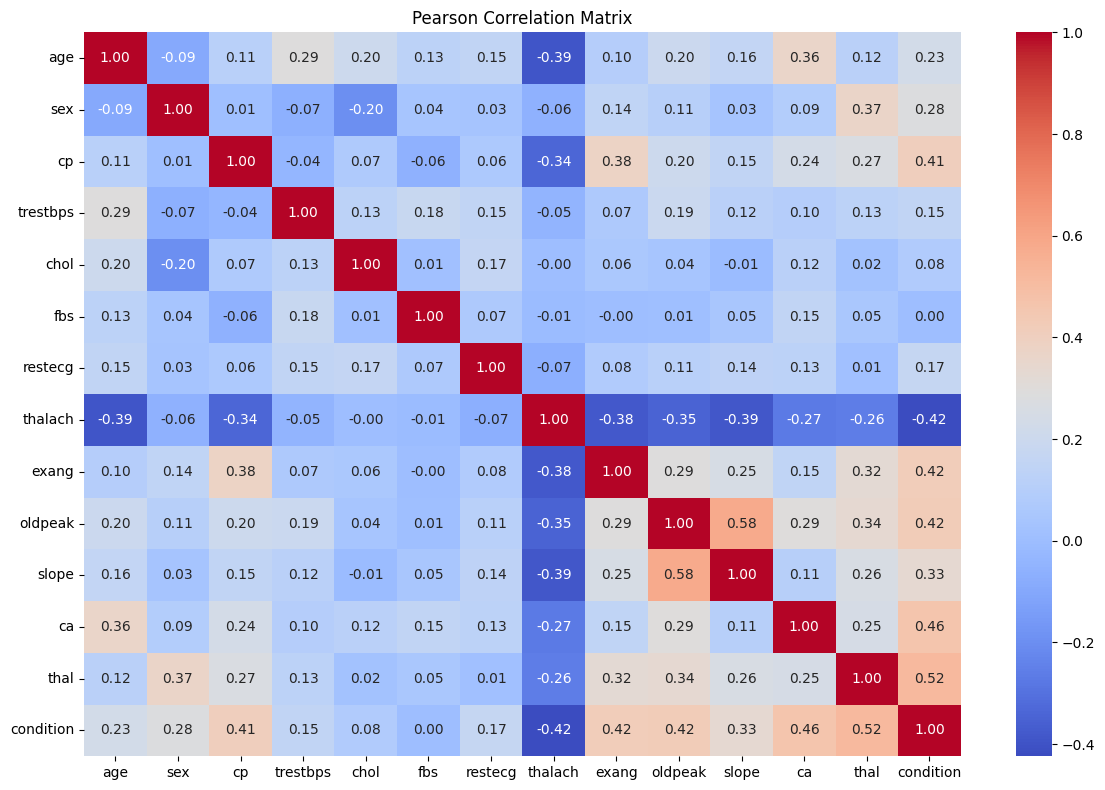

In [30]:
corr_matrix = df.corr(method="pearson")
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

### Distribution of 'Condition' (Target Variable)

/tmp/ipykernel_1873/3853254477.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette='viridis')


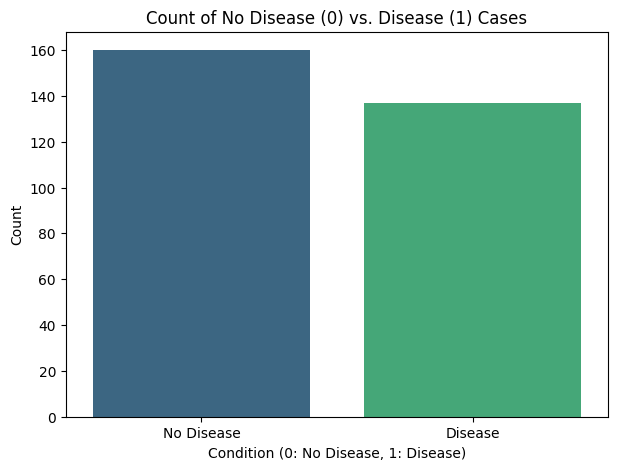

Counts for 'condition' column:
condition
0    160
1    137
Name: count, dtype: int64


In [31]:
condition_counts = df['condition'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=condition_counts.index, y=condition_counts.values, palette='viridis')
plt.title('Count of No Disease (0) vs. Disease (1) Cases')
plt.xlabel('Condition (0: No Disease, 1: Disease)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'])
plt.show()

print("Counts for 'condition' column:")
print(condition_counts)

### Distribution of Numerical Features

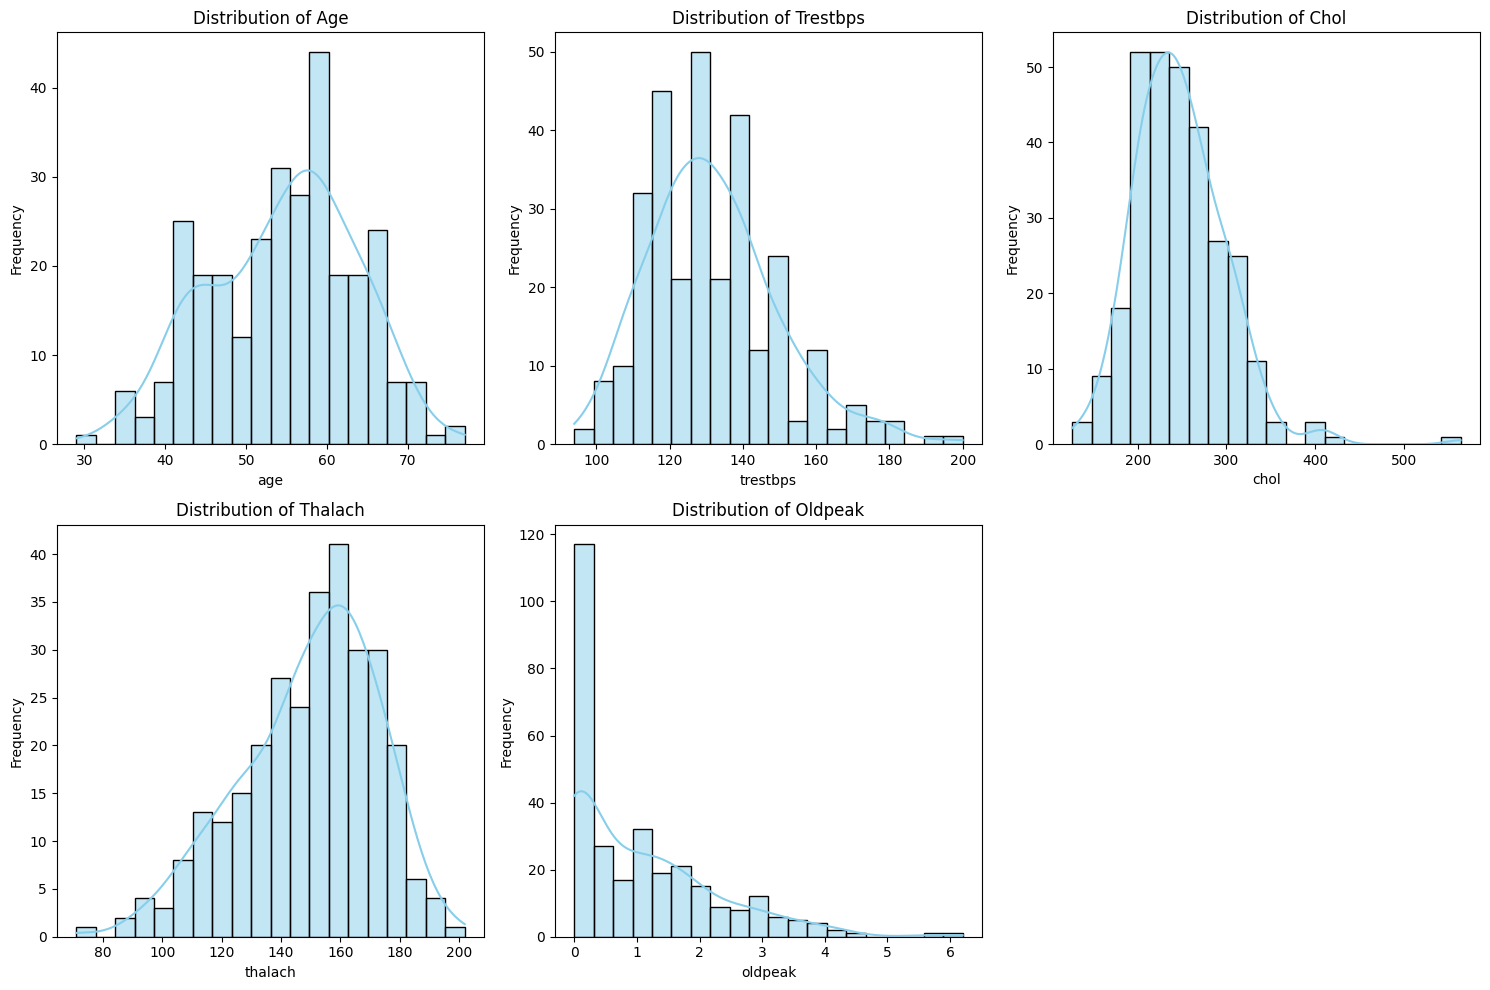

In [32]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

/tmp/ipykernel_1873/2500004684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1873/2500004684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1873/2500004684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1873/2500004684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

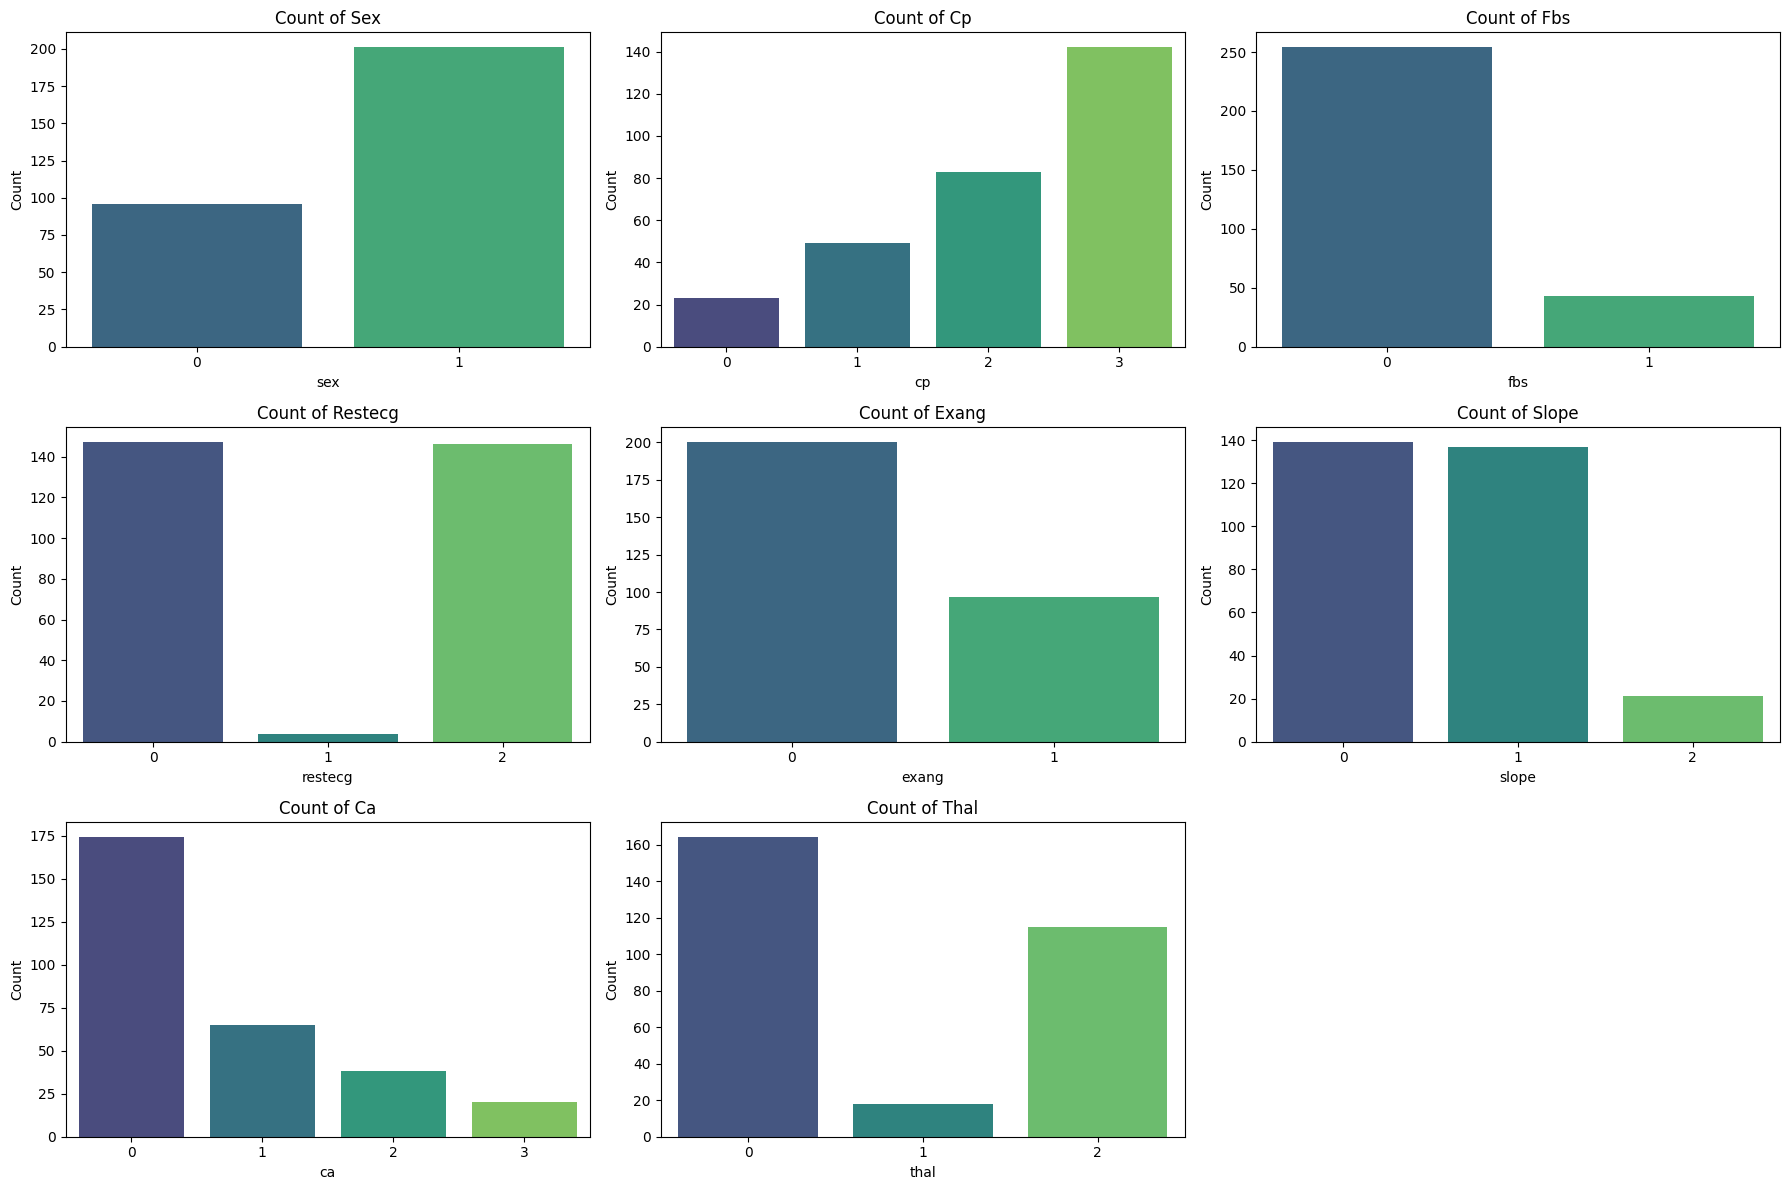

In [33]:
categorical_features_for_plots = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features_for_plots):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count of {col.capitalize()}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Numerical Feature Distributions by Condition

/tmp/ipykernel_1873/1895562256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y=col, data=df, palette='pastel')
/tmp/ipykernel_1873/1895562256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y=col, data=df, palette='pastel')
/tmp/ipykernel_1873/1895562256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y=col, data=df, palette='pastel')
/tmp/ipykernel_1873/1895562256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign th

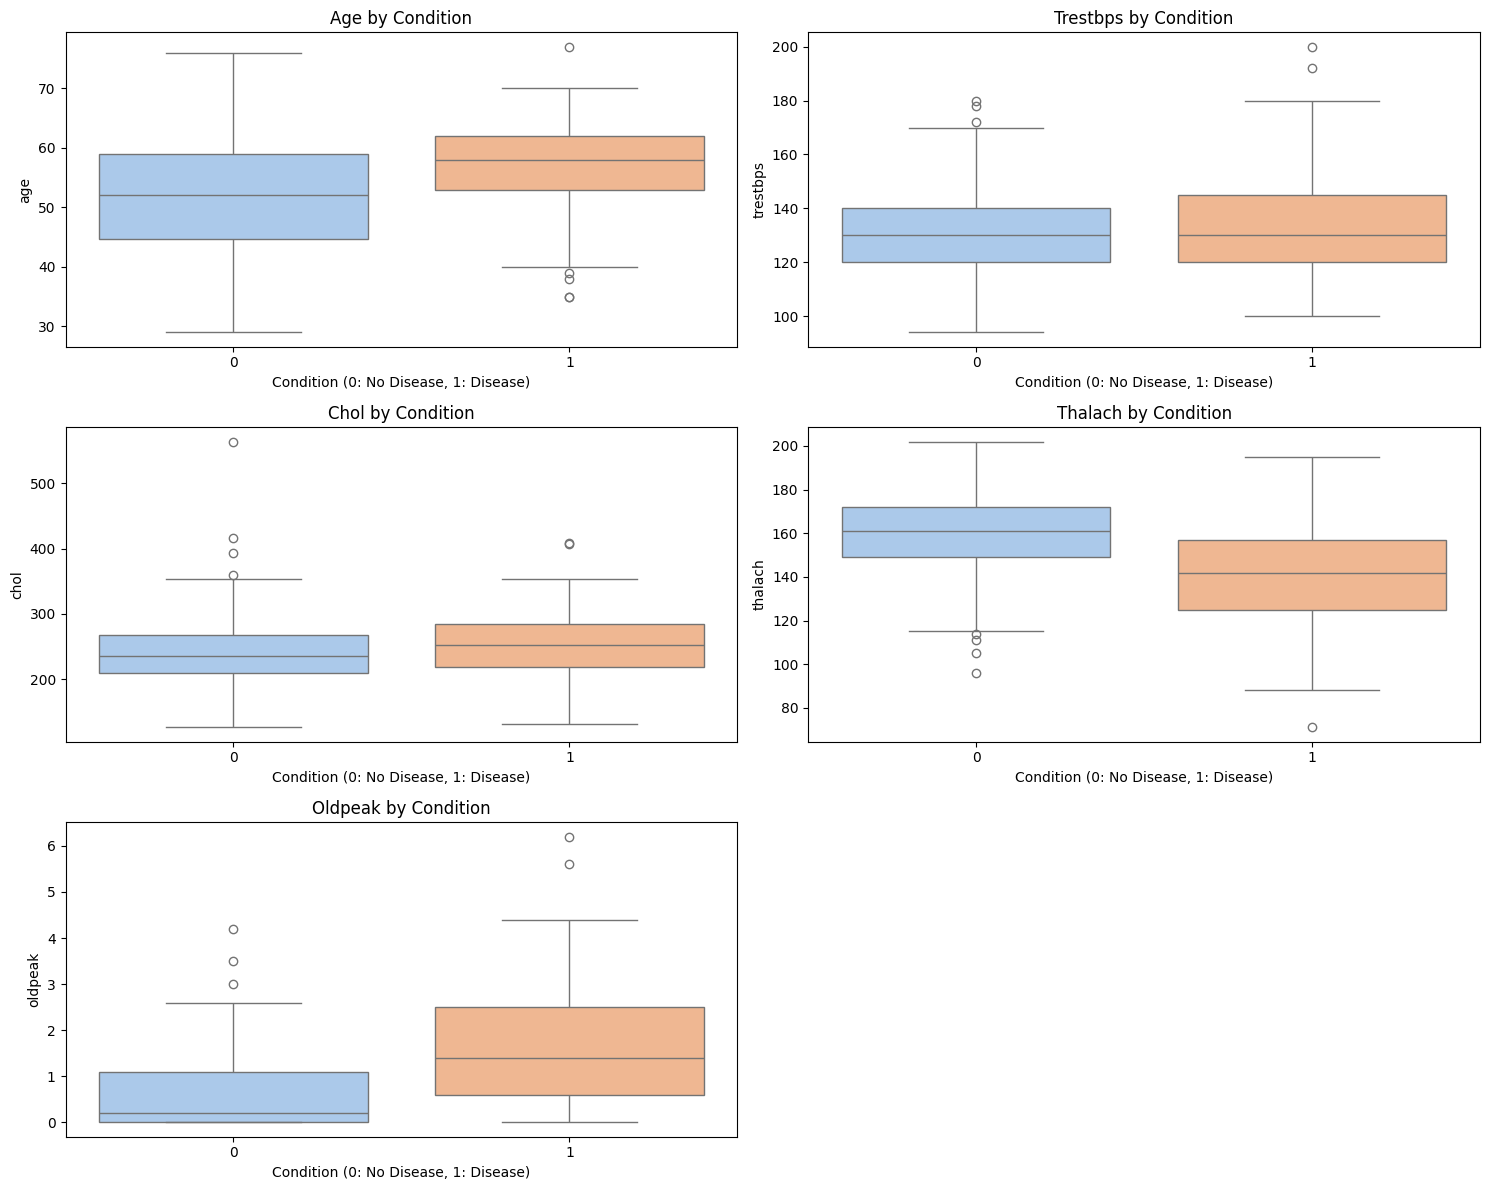

In [34]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='condition', y=col, data=df, palette='pastel')
    plt.title(f'{col.capitalize()} by Condition')
    plt.xlabel('Condition (0: No Disease, 1: Disease)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Split Features and Target

In [35]:
X = df.drop("condition", axis=1)
y = df["condition"]

# Categorical (nominal, not ordinal) vs numeric columns.
# cp, restecg, slope, ca, thal encode categories, not magnitudes,
# so one-hot encoding is more appropriate for the linear model.
CATEGORICAL_COLS = ["cp", "restecg", "slope", "ca", "thal"]
NUMERIC_COLS = [c for c in X.columns if c not in CATEGORICAL_COLS]

## Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)
# This dataset has one row per patient, so there is no
# patient-level leakage risk here.

## Preprocessing

In [37]:
lr_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
])

## Model Pipelines

In [38]:
lr_pipeline = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)),
])

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=RANDOM_SEED)),
])

## Hyperparameter Grids

In [39]:
lr_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
}

rf_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__class_weight": [None, "balanced"],
}

## Nested Cross-Validation

In [40]:
from sklearn.metrics import make_scorer, recall_score

specificity_scorer = make_scorer(recall_score, pos_label=0)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

SCORING = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc", "specificity": specificity_scorer}

lr_search = GridSearchCV(lr_pipeline, lr_grid, cv=inner_cv, scoring="roc_auc")
lr_scores = cross_validate(
    lr_search, X_train, y_train, cv=outer_cv, scoring=SCORING
)

rf_search = GridSearchCV(rf_pipeline, rf_grid, cv=inner_cv, scoring="roc_auc")
rf_scores = cross_validate(
    rf_search, X_train, y_train, cv=outer_cv, scoring=SCORING
)

## Compare Models

In [41]:
print("Logistic Regression (nested CV, mean over outer folds)")
print("  Accuracy :", lr_scores["test_accuracy"].mean())
print("  Precision:", lr_scores["test_precision"].mean())
print("  Recall   :", lr_scores["test_recall"].mean())
print("  Specificity:", lr_scores["test_specificity"].mean())
print("  F1       :", lr_scores["test_f1"].mean())
print("  ROC-AUC  :", lr_scores["test_roc_auc"].mean())

print()
print("Random Forest (nested CV, mean over outer folds)")
print("  Accuracy :", rf_scores["test_accuracy"].mean())
print("  Precision:", rf_scores["test_precision"].mean())
print("  Recall   :", rf_scores["test_recall"].mean())
print("  Specificity:", rf_scores["test_specificity"].mean())
print("  F1       :", rf_scores["test_f1"].mean())
print("  ROC-AUC  :", rf_scores["test_roc_auc"].mean())

Logistic Regression (nested CV, mean over outer folds)
  Accuracy : 0.801950354609929
  Precision: 0.7971367813473077
  Recall   : 0.7632034632034632
  Specificity: 0.836
  F1       : 0.7770465861106814
  ROC-AUC  : 0.8867026307026308

Random Forest (nested CV, mean over outer folds)
  Accuracy : 0.801950354609929
  Precision: 0.8010192147034253
  Recall   : 0.7541125541125542
  Specificity: 0.8436923076923076
  F1       : 0.774185956477505
  ROC-AUC  : 0.8885454545454545


## Visual Comparison of Logistic Regression and Random Forest Model Performance

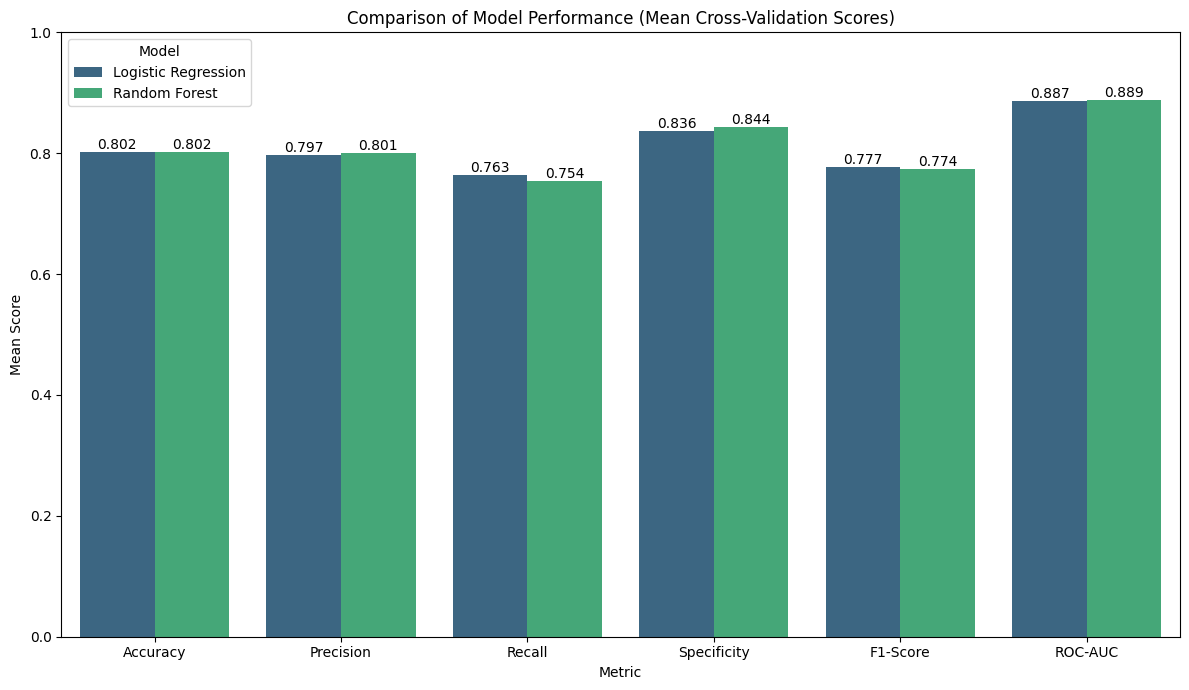

In [42]:
metrics = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'ROC-AUC']

# Prepare data for plotting
data = {
    'Model': [],
    'Metric': [],
    'Score': []
}

for i, metric in enumerate(metrics):
    data['Model'].append('Logistic Regression')
    data['Metric'].append(metric_names[i])
    data['Score'].append(lr_scores[f"test_{metric}"].mean())

    data['Model'].append('Random Forest')
    data['Metric'].append(metric_names[i])
    data['Score'].append(rf_scores[f"test_{metric}"].mean())

comparison_df = pd.DataFrame(data)

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_df, palette='viridis')
plt.title('Comparison of Model Performance (Mean Cross-Validation Scores)')
plt.ylabel('Mean Score')
plt.xlabel('Metric')
plt.ylim(0.0, 1.0) # Scores are typically between 0 and 1
plt.legend(title='Model')

# Add score values on top of bars for clarity
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

## Select and Train the Best Model on the Entire Training Set

In [43]:
lr_mean_auc = lr_scores["test_roc_auc"].mean()
rf_mean_auc = rf_scores["test_roc_auc"].mean()

if lr_mean_auc >= rf_mean_auc:
    print(f"Selected model: Logistic Regression (CV ROC-AUC {lr_mean_auc:.4f} "
          f"vs RF {rf_mean_auc:.4f})")
    final_search = lr_search
    model_name = "Logistic Regression"
else:
    print(f"Selected model: Random Forest (CV ROC-AUC {rf_mean_auc:.4f} "
          f"vs LR {lr_mean_auc:.4f})")
    final_search = rf_search
    model_name = "Random Forest"

final_search.fit(X_train, y_train)
best_model = final_search.best_estimator_
print("Best hyperparameters:", final_search.best_params_)

Selected model: Random Forest (CV ROC-AUC 0.8885 vs LR 0.8867)
Best hyperparameters: {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 100}


## Test Evaluation

In [44]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Compute confusion matrix values for specificity
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)  # True Negative Rate

print(f"Test set performance ({model_name}, threshold=0.5)")
print("Accuracy    :", accuracy_score(y_test, y_pred))
print("Precision   :", precision_score(y_test, y_pred))
print("Recall (Sens):", recall_score(y_test, y_pred))   # Sensitivity = TP/(TP+FN)
print("Specificity  :", specificity)                    # Specificity = TN/(TN+FP)
print("F1           :", f1_score(y_test, y_pred))
print("ROC-AUC      :", roc_auc_score(y_test, y_prob))
print()
print("Confusion matrix breakdown:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print()
print("Interpretation:")
print(f"  The model correctly ruled out disease in {specificity:.1%} of healthy patients (specificity).")
print(f"  It correctly detected disease in {recall_score(y_test, y_pred):.1%} of sick patients (sensitivity).")


Test set performance (Random Forest, threshold=0.5)
Accuracy    : 0.85
Precision   : 0.9130434782608695
Recall (Sens): 0.75
Specificity  : 0.9375
F1           : 0.8235294117647058
ROC-AUC      : 0.9397321428571428

Confusion matrix breakdown:
  TN=30  FP=2
  FN=7  TP=21

Interpretation:
  The model correctly ruled out disease in 93.8% of healthy patients (specificity).
  It correctly detected disease in 75.0% of sick patients (sensitivity).


## Confusion Matrix

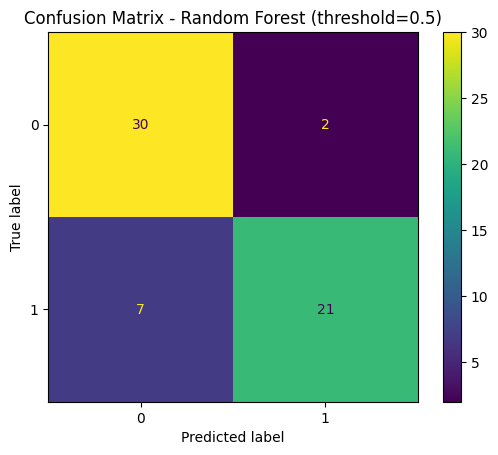

In [45]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title(f"Confusion Matrix - {model_name} (threshold=0.5)")
plt.show()

## ROC Curve

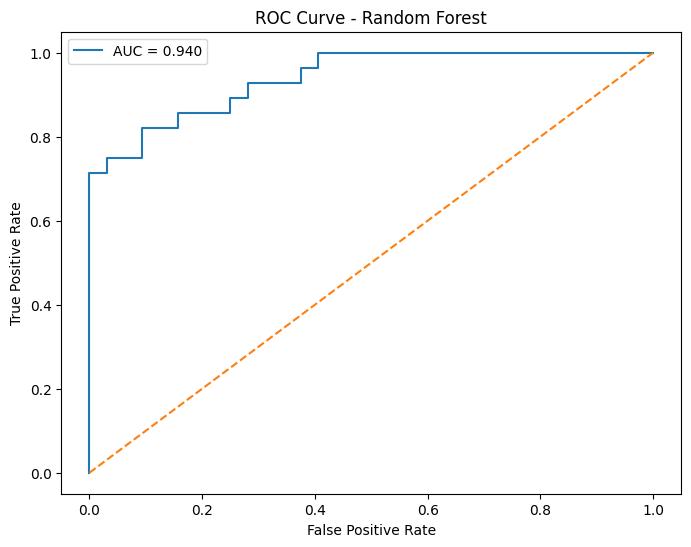

In [46]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {model_name}")
plt.legend()
plt.show()

## Threshold Analysis

In [47]:
print(f"{'Threshold':>10} {'Precision':>10} {'Sensitivity':>12} {'Specificity':>12} {'F1':>8}")
print("-" * 58)
for t in [0.3, 0.4, 0.5, 0.6]:
    custom_pred = (y_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, custom_pred).ravel()
    p   = precision_score(y_test, custom_pred, zero_division=0)
    sen = recall_score(y_test, custom_pred, zero_division=0)        # sensitivity
    spe = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0.0      # specificity
    f   = f1_score(y_test, custom_pred, zero_division=0)
    print(f"{t:>10.1f} {p:>10.3f} {sen:>12.3f} {spe:>12.3f} {f:>8.3f}")
print()
print("Note: lowering the threshold raises sensitivity (fewer missed cases)")
print("      but lowers specificity (more healthy patients falsely flagged).")
print("      Choose the operating threshold based on the clinical use case.")


 Threshold  Precision  Sensitivity  Specificity       F1
----------------------------------------------------------
       0.3      0.683        1.000        0.594    0.812
       0.4      0.800        0.857        0.812    0.828
       0.5      0.913        0.750        0.938    0.824
       0.6      1.000        0.679        1.000    0.809

Note: lowering the threshold raises sensitivity (fewer missed cases)
      but lowers specificity (more healthy patients falsely flagged).
      Choose the operating threshold based on the clinical use case.


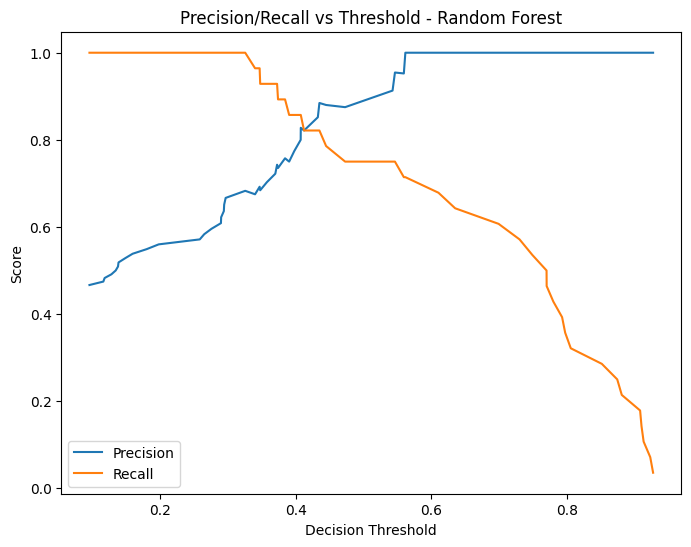

In [48]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(pr_thresholds, precisions[:-1], label="Precision")
plt.plot(pr_thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title(f"Precision/Recall vs Threshold - {model_name}")
plt.legend()
plt.show()

## Feature Importance / Interpretability

Feature importances (Random Forest):
     feature  importance
2         cp    0.171675
7    thalach    0.166016
11        ca    0.152570
12      thal    0.135466
9    oldpeak    0.122715
8      exang    0.079649
0        age    0.059350
10     slope    0.040188
3   trestbps    0.028838
4       chol    0.021718
1        sex    0.012678
6    restecg    0.007869
5        fbs    0.001269


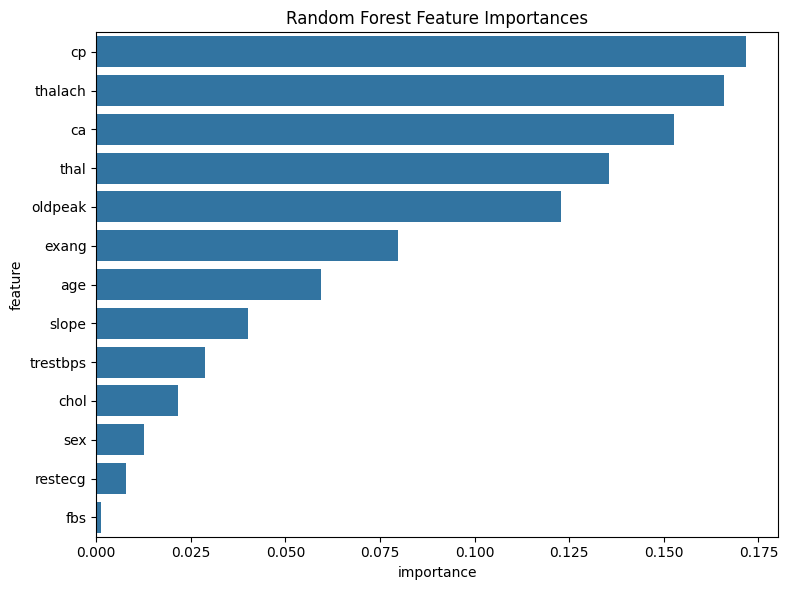

In [49]:
if model_name == "Random Forest":
    importances = best_model.named_steps["model"].feature_importances_
    feat_names = X_train.columns
    importance_df = pd.DataFrame({
        "feature": feat_names, "importance": importances
    }).sort_values("importance", ascending=False)
    print("Feature importances (Random Forest):")
    print(importance_df)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title("Random Forest Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(CATEGORICAL_COLS)
    all_feature_names = np.concatenate([NUMERIC_COLS, cat_feature_names])

    coefs = best_model.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": all_feature_names, "coefficient": coefs
    }).sort_values("coefficient", key=np.abs, ascending=False)
    print("Standardized coefficients (Logistic Regression):")
    print(coef_df)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=coef_df, x="coefficient", y="feature")
    plt.title("Logistic Regression Coefficients (standardized features)")
    plt.tight_layout()
    plt.show()